# Refinamiento del modelo final: XGBoost + ROS

Este notebook refina el modelo seleccionado en `05_modelamiento_dl.ipynb`
(XGBoost + ROS) en dos etapas independientes:

1. **Búsqueda de hiperparámetros**, mediante validación cruzada estratificada
   dentro del conjunto de entrenamiento únicamente.
2. **Ajuste del umbral de decisión**, sobre el conjunto de validación.

La búsqueda de hiperparámetros y la selección del umbral se deciden exclusivamente con evidencia de entrenamiento y validación. El conjunto de prueba se evalúa con la configuración definitiva como lectura final adoptada. Cabe transparentar que, durante el desarrollo, también se obtuvo una lectura exploratoria de prueba con un umbral que luego fue descartado (ver sección 4 y las conclusiones); esa lectura no participó en la decisión de corregir el umbral, que se basó únicamente en el recall observado en validación.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from pathlib import Path

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    precision_recall_curve,
)
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Carga de artefactos y del modelo baseline

Se cargan los mismos splits preprocesados usados en todos los notebooks
anteriores, y el modelo `xgboost_final.joblib` (el baseline que se busca
refinar) para poder compararlos en las mismas condiciones.

In [2]:
ruta_artefactos = Path("../artifacts")
ruta_modelos = Path("../models")
ruta_figuras = Path("../figures")
ruta_figuras.mkdir(exist_ok=True)

artefactos = joblib.load(ruta_artefactos / "splits_preprocesados.joblib")

X_train = artefactos["X_train"]
X_val = artefactos["X_val"]
X_test = artefactos["X_test"]
y_train = artefactos["y_train"]
y_val = artefactos["y_val"]
y_test = artefactos["y_test"]

modelo_baseline = joblib.load(ruta_modelos / "xgboost_final.joblib")

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (7000, 58)
X_val: (1500, 58)
X_test: (1500, 58)


## 2. Búsqueda de hiperparámetros (solo entrenamiento, validación cruzada)

Se usa un pipeline de `imbalanced-learn` que aplica `RandomOverSampler`
únicamente sobre el pliegue de entrenamiento de cada fold de la validación
cruzada, y se evalúa sobre el pliegue de prueba de ese fold **sin
remuestrear**, igual que se hace con validación y prueba en el resto del
proyecto. El conjunto de validación (`X_val`) no participa en esta etapa: se
reserva para el ajuste de umbral de la sección siguiente.

Se optimiza **PR-AUC** (`average_precision`) en vez de F1, porque no depende
de un umbral de decisión arbitrario y es la métrica más informativa cuando la
clase positiva es minoritaria.

In [3]:
pipeline_busqueda = ImbPipeline([
    ("ros", RandomOverSampler(random_state=RANDOM_STATE)),
    ("clf", XGBClassifier(
        random_state=RANDOM_STATE,
        eval_metric="logloss",
        n_jobs=1,
    )),
])

espacio_busqueda = {
    "clf__max_depth": [2, 3, 4, 5],
    "clf__learning_rate": [0.02, 0.05, 0.1],
    "clf__n_estimators": [150, 250, 400],
    "clf__subsample": [0.7, 0.8, 1.0],
    "clf__colsample_bytree": [0.7, 0.8, 1.0],
    "clf__min_child_weight": [1, 3, 5],
    "clf__gamma": [0, 0.5, 1.0],
    "clf__reg_alpha": [0, 0.5, 1.0],
    "clf__reg_lambda": [1.0, 2.0, 5.0],
}

busqueda = RandomizedSearchCV(
    estimator=pipeline_busqueda,
    param_distributions=espacio_busqueda,
    n_iter=35,
    scoring="average_precision",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True,
)

busqueda.fit(X_train, y_train)

print("Mejor PR-AUC en validación cruzada:", round(busqueda.best_score_, 4))
print("\nMejores hiperparámetros:")
for nombre, valor in busqueda.best_params_.items():
    print(f"  {nombre.replace('clf__', '')}: {valor}")

Mejor PR-AUC en validación cruzada: 0.3202

Mejores hiperparámetros:
  subsample: 0.7
  reg_lambda: 1.0
  reg_alpha: 0
  n_estimators: 250
  min_child_weight: 5
  max_depth: 2
  learning_rate: 0.02
  gamma: 0
  colsample_bytree: 0.7


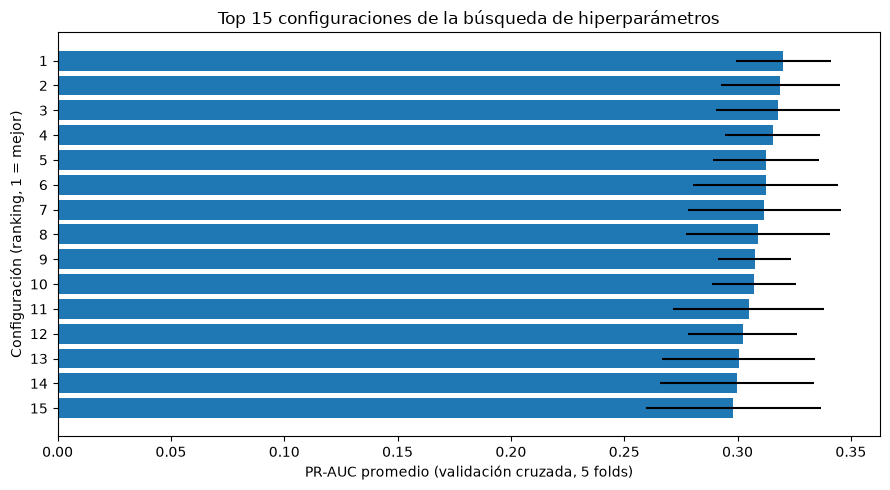

In [4]:
resultados_busqueda = pd.DataFrame(busqueda.cv_results_).sort_values(
    "mean_test_score", ascending=False
).head(15).reset_index(drop=True)

ranking = np.arange(1, len(resultados_busqueda) + 1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(
    ranking.astype(str),
    resultados_busqueda["mean_test_score"],
    xerr=resultados_busqueda["std_test_score"],
)
ax.set_xlabel("PR-AUC promedio (validación cruzada, 5 folds)")
ax.set_ylabel("Configuración (ranking, 1 = mejor)")
ax.set_title("Top 15 configuraciones de la búsqueda de hiperparámetros")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(ruta_figuras / "11_01_busqueda_hiperparametros.png", dpi=150)
plt.show()

## 3. Modelo refinado

`RandomizedSearchCV` con `refit=True` vuelve a entrenar automáticamente el
mejor pipeline (ROS + XGBoost) sobre **todo** `X_train`. Se extrae el
clasificador ya ajustado desde ese pipeline: es exactamente el mismo modelo
que se obtendría entrenando un `XGBClassifier` con los hiperparámetros
ganadores sobre `X_train` remuestreado con ROS, como se hizo con el
baseline.

In [5]:
modelo_refinado = busqueda.best_estimator_.named_steps["clf"]

mejores_hiperparametros = {
    nombre.replace("clf__", ""): valor
    for nombre, valor in busqueda.best_params_.items()
}

with open(ruta_modelos / "mejores_hiperparametros_xgboost.json", "w", encoding="utf-8") as f:
    json.dump(mejores_hiperparametros, f, indent=2, ensure_ascii=False)

print("Hiperparámetros guardados:", mejores_hiperparametros)

Hiperparámetros guardados: {'subsample': 0.7, 'reg_lambda': 1.0, 'reg_alpha': 0, 'n_estimators': 250, 'min_child_weight': 5, 'max_depth': 2, 'learning_rate': 0.02, 'gamma': 0, 'colsample_bytree': 0.7}


## 4. Ajuste del umbral de decisión (sobre validación)

Con los hiperparámetros ya fijos, se calculan las probabilidades sobre `X_val` y se recorren distintos umbrales para observar cómo cambian precision, recall y F1.

**Criterio de selección.** El primer intento fue elegir el umbral que maximiza F1 en validación. Ese umbral (0,66) sí mejoraba el F1, pero hundía el recall de validación de 0,843 a 0,569 — una caída que contradice directamente la prioridad de negocio declarada desde la sección 5.3 del informe: se prioriza recall porque no detectar a un cliente que abandonará impide accionar la retención. Maximizar F1 en un conjunto de validación pequeño (153 casos positivos) optimiza un promedio agregado, no la restricción de negocio real. **El umbral 0,66 se descartó por su bajo recall en validación (0,569); esa caída, por sí sola, ya bastaba para rechazarlo.** Durante el desarrollo se obtuvo además una lectura exploratoria sobre el conjunto de prueba con ese umbral (recall 0,44 — ver conclusiones), pero esta no se utilizó para seleccionar el umbral definitivo: la decisión de corregir el criterio se tomó únicamente a partir de la evidencia de validación. Por eso se corrige el criterio: se adopta como umbral de decisión el que **mantiene recall ≥ 0,80 en validación mientras maximiza la precision** dentro de esa restricción, en vez de maximizar F1 sin restricciones. Se documenta igualmente el umbral F1-máximo como referencia, para dejar explícita la razón del descarte.

In [6]:
proba_val_refinado = modelo_refinado.predict_proba(X_val)[:, 1]

umbrales = np.linspace(0.05, 0.95, 181)
resultados_umbral = []

for umbral in umbrales:
    prediccion = (proba_val_refinado >= umbral).astype(int)
    resultados_umbral.append({
        "umbral": umbral,
        "precision": precision_score(y_val, prediccion, zero_division=0),
        "recall": recall_score(y_val, prediccion, zero_division=0),
        "f1": f1_score(y_val, prediccion, zero_division=0),
    })

tabla_umbrales = pd.DataFrame(resultados_umbral)

umbral_optimo_f1 = tabla_umbrales.loc[tabla_umbrales["f1"].idxmax(), "umbral"]

candidatos_recall_80 = tabla_umbrales[tabla_umbrales["recall"] >= 0.80]
umbral_recall_80 = (
    candidatos_recall_80.loc[candidatos_recall_80["precision"].idxmax(), "umbral"]
    if len(candidatos_recall_80) > 0
    else 0.5
)

candidatos_recall_90 = tabla_umbrales[tabla_umbrales["recall"] >= 0.90]
umbral_recall_90 = (
    candidatos_recall_90.loc[candidatos_recall_90["precision"].idxmax(), "umbral"]
    if len(candidatos_recall_90) > 0
    else tabla_umbrales["umbral"].min()
)

# Umbral de decisión definitivo: recall >= 0.80 en validación (no el
# máximo F1 — ver justificación en la celda de markdown anterior).
umbral_decision = umbral_recall_80

print(f"Umbral que maximiza F1 en validación (descartado): {umbral_optimo_f1:.3f}")
print(f"Umbral de decisión definitivo (recall >= 0.80): {umbral_decision:.3f}")
print(f"Umbral de referencia para banda 'Bajo' (recall >= 0.90): {umbral_recall_90:.3f}")

Umbral que maximiza F1 en validación (descartado): 0.660
Umbral de decisión definitivo (recall >= 0.80): 0.560
Umbral de referencia para banda 'Bajo' (recall >= 0.90): 0.240


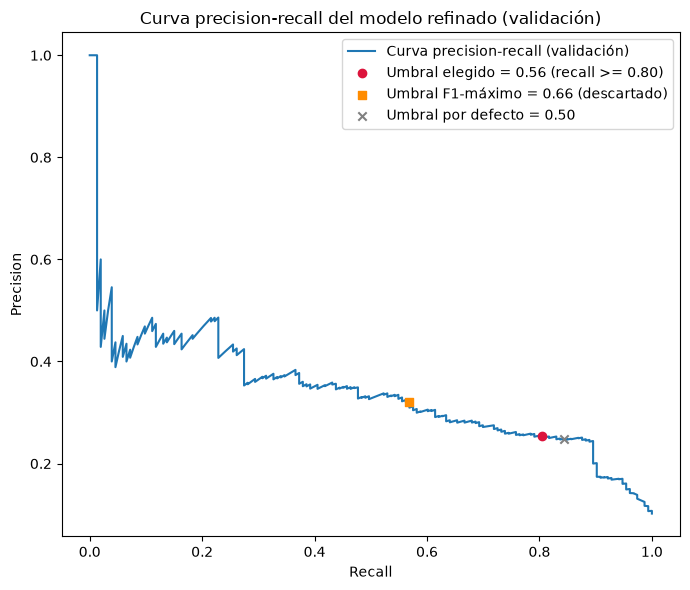

In [7]:
precision_curva, recall_curva, umbrales_curva = precision_recall_curve(y_val, proba_val_refinado)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(recall_curva, precision_curva, label="Curva precision-recall (validación)")

idx_decision = np.argmin(np.abs(umbrales_curva - umbral_decision))
ax.scatter(
    recall_curva[idx_decision], precision_curva[idx_decision],
    color="crimson", zorder=5,
    label=f"Umbral elegido = {umbral_decision:.2f} (recall >= 0.80)",
)

idx_f1 = np.argmin(np.abs(umbrales_curva - umbral_optimo_f1))
ax.scatter(
    recall_curva[idx_f1], precision_curva[idx_f1],
    color="darkorange", marker="s", zorder=5,
    label=f"Umbral F1-máximo = {umbral_optimo_f1:.2f} (descartado)",
)

pred_050 = (proba_val_refinado >= 0.5).astype(int)
recall_050 = recall_score(y_val, pred_050)
precision_050 = precision_score(y_val, pred_050, zero_division=0)

ax.scatter(
    [recall_050],
    [precision_050],
    color="gray",
    marker="x",
    zorder=5,
    label="Umbral por defecto = 0.50",
)

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Curva precision-recall del modelo refinado (validación)")
ax.legend()
plt.tight_layout()
plt.savefig(ruta_figuras / "11_02_curva_precision_recall_umbral.png", dpi=150)
plt.show()

### Bandas de riesgo

A partir de los mismos cortes se definen tres bandas de riesgo, que el prototipo utilizará para mostrar un nivel en vez de solo una probabilidad cruda: **Bajo** por debajo del umbral de referencia (recall ≥ 0,90), **Medio** entre ese umbral y el umbral de decisión (recall ≥ 0,80), y **Alto** desde el umbral de decisión hacia arriba.

In [8]:
configuracion_umbral = {
    "modelo": "xgboost_refinado.joblib",
    "umbral_decision": round(float(umbral_decision), 3),
    "banda_bajo": round(float(umbral_recall_90), 3),
    "metodo": "recall_minimo_0.80_validacion",
    "umbral_f1_max_descartado": round(float(umbral_optimo_f1), 3),
    "justificacion": (
        "Se descartó el umbral que maximiza F1 (0.66) porque bajaba el "
        "recall de validación a 0.569, en contra de la prioridad de "
        "negocio del proyecto. Se adoptó en su lugar el umbral que "
        "mantiene recall >= 0.80 maximizando precision dentro de esa "
        "restricción."
    ),
    "bandas_riesgo": {
        "Bajo": f"probabilidad < {round(float(umbral_recall_90), 3)}",
        "Medio": f"{round(float(umbral_recall_90), 3)} <= probabilidad < {round(float(umbral_decision), 3)}",
        "Alto": f"probabilidad >= {round(float(umbral_decision), 3)}",
    },
}

with open(ruta_modelos / "config_umbral.json", "w", encoding="utf-8") as f:
    json.dump(configuracion_umbral, f, indent=2, ensure_ascii=False)

configuracion_umbral

{'modelo': 'xgboost_refinado.joblib',
 'umbral_decision': 0.56,
 'banda_bajo': 0.24,
 'metodo': 'recall_minimo_0.80_validacion',
 'umbral_f1_max_descartado': 0.66,
 'justificacion': 'Se descartó el umbral que maximiza F1 (0.66) porque bajaba el recall de validación a 0.569, en contra de la prioridad de negocio del proyecto. Se adoptó en su lugar el umbral que mantiene recall >= 0.80 maximizando precision dentro de esa restricción.',
 'bandas_riesgo': {'Bajo': 'probabilidad < 0.24',
  'Medio': '0.24 <= probabilidad < 0.56',
  'Alto': 'probabilidad >= 0.56'}}

## 5. Comparación baseline vs. refinado (validación)

Se separan los dos efectos para que quede claro qué aportó cada etapa del
refinamiento:

1. **Baseline**: hiperparámetros originales, umbral 0,5.
2. **Refinado (umbral 0,5)**: solo el efecto de los nuevos hiperparámetros.
3. **Refinado (umbral ajustado)**: la configuración definitiva.

In [9]:
def evaluar(modelo, X, y_true, umbral):
    proba = modelo.predict_proba(X)[:, 1]
    prediccion = (proba >= umbral).astype(int)
    return {
        "accuracy": accuracy_score(y_true, prediccion),
        "precision": precision_score(y_true, prediccion, zero_division=0),
        "recall": recall_score(y_true, prediccion, zero_division=0),
        "f1": f1_score(y_true, prediccion, zero_division=0),
        "roc_auc": roc_auc_score(y_true, proba),
        "pr_auc": average_precision_score(y_true, proba),
    }


comparacion = pd.DataFrame([
    {"configuracion": "Baseline (umbral 0.50)", **evaluar(modelo_baseline, X_val, y_val, 0.5)},
    {"configuracion": "Refinado (umbral 0.50)", **evaluar(modelo_refinado, X_val, y_val, 0.5)},
    {"configuracion": f"Refinado (umbral {umbral_decision:.2f}, recall>=0.80)", **evaluar(modelo_refinado, X_val, y_val, umbral_decision)},
]).set_index("configuracion").round(3)

comparacion.to_csv(ruta_modelos / "comparacion_baseline_refinado_validacion.csv")
comparacion

,accuracy,precision,recall,f1,roc_auc,pr_auc
configuracion,,,,,,
Baseline (umbral 0.50),0.737,0.259,0.843,0.396,0.826,0.333
Refinado (umbral 0.50),0.724,0.249,0.843,0.384,0.829,0.341
"Refinado (umbral 0.56, recall>=0.80)",0.740,0.255,0.804,0.387,0.829,0.341


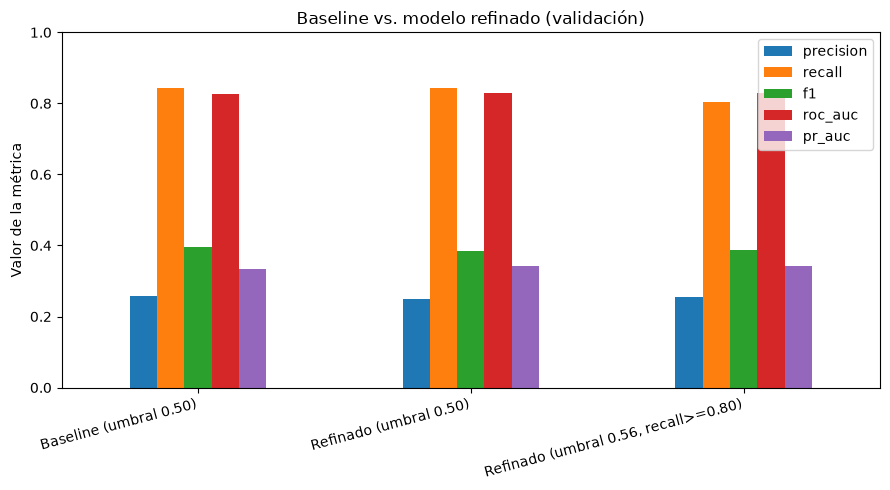

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
comparacion[["precision", "recall", "f1", "roc_auc", "pr_auc"]].plot(kind="bar", ax=ax)
ax.set_title("Baseline vs. modelo refinado (validación)")
ax.set_ylabel("Valor de la métrica")
ax.set_xlabel("")
ax.set_ylim(0, 1)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig(ruta_figuras / "11_03_comparacion_baseline_refinado.png", dpi=150)
plt.show()

## 6. Evaluación final en prueba

Se evalúa la configuración definitiva (hiperparámetros refinados + umbral ajustado por recall ≥ 0,80) sobre el conjunto de prueba, reservado desde el notebook 02. Como se documenta en la sección 4 y en las conclusiones, el conjunto de prueba tuvo una lectura exploratoria previa con el umbral F1-máximo (0,66), que ya había sido descartado por su bajo recall en validación antes de esa lectura; esa lectura exploratoria no influyó en la elección del umbral definitivo, que se decidió únicamente con evidencia de validación.

In [11]:
metricas_test_refinado = evaluar(modelo_refinado, X_test, y_test, umbral_decision)

print(f"Métricas del modelo refinado en prueba (umbral {umbral_decision:.2f}, recall>=0.80 en validación):")
for nombre, valor in metricas_test_refinado.items():
    print(f"  {nombre}: {valor:.3f}")

pd.Series(metricas_test_refinado).round(3).to_csv(ruta_modelos / "metricas_test_modelo_refinado.csv")

Métricas del modelo refinado en prueba (umbral 0.56, recall>=0.80 en validación):
  accuracy: 0.721
  precision: 0.234
  recall: 0.765
  f1: 0.359
  roc_auc: 0.782
  pr_auc: 0.302


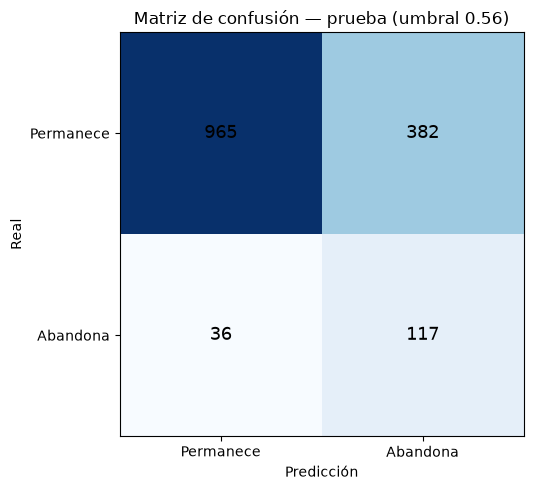

array([[965, 382],
       [ 36, 117]])

In [12]:
proba_test_refinado = modelo_refinado.predict_proba(X_test)[:, 1]
prediccion_test_refinado = (proba_test_refinado >= umbral_decision).astype(int)
matriz_test_refinado = confusion_matrix(y_test, prediccion_test_refinado)

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.imshow(matriz_test_refinado, cmap="Blues")
ax.set_title(f"Matriz de confusión — prueba (umbral {umbral_decision:.2f})")
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Permanece", "Abandona"])
ax.set_yticklabels(["Permanece", "Abandona"])

for i in range(2):
    for j in range(2):
        ax.text(j, i, matriz_test_refinado[i, j], ha="center", va="center", fontsize=13)

plt.tight_layout()
plt.savefig(ruta_figuras / "11_04_matriz_confusion_refinado_test.png", dpi=150)
plt.show()

matriz_test_refinado

## 7. Guardado del modelo definitivo y del esquema de entrada

Se guarda el modelo refinado (sin sobrescribir `xgboost_final.joblib`, que queda como referencia del baseline) y un esquema con los rangos y categorías de las 30 variables originales, a partir del dataset depurado. Este esquema lo utilizará el formulario del prototipo para mostrar valores por defecto razonables y validar las entradas.

In [13]:
joblib.dump(modelo_refinado, ruta_modelos / "xgboost_refinado.joblib")

df_limpio = pd.read_csv(
    "../data/processed/customer_churn_clean.csv",
    keep_default_na=False,
    na_values=[""],
)

columnas_excluidas = ["customer_id", "churn"]
variables_numericas = (
    df_limpio.drop(columns=columnas_excluidas)
    .select_dtypes(include=["int64", "float64"])
    .columns
    .tolist()
)
variables_categoricas = (
    df_limpio.drop(columns=columnas_excluidas)
    .select_dtypes(include=["object", "str", "category"])
    .columns
    .tolist()
)

esquema_entrada = {"numericas": {}, "categoricas": {}}

for variable in variables_numericas:
    esquema_entrada["numericas"][variable] = {
        "min": float(df_limpio[variable].min()),
        "max": float(df_limpio[variable].max()),
        "mediana": float(df_limpio[variable].median()),
    }

for variable in variables_categoricas:
    esquema_entrada["categoricas"][variable] = {
        "valores": sorted(df_limpio[variable].unique().tolist()),
        "default": df_limpio[variable].mode().iloc[0],
    }

with open(Path("../artifacts") / "esquema_entrada.json", "w", encoding="utf-8") as f:
    json.dump(esquema_entrada, f, indent=2, ensure_ascii=False)

print("Variables numéricas:", len(variables_numericas))
print("Variables categóricas:", len(variables_categoricas))
print("Esquema guardado en artifacts/esquema_entrada.json")

Variables numéricas: 19
Variables categóricas: 11
Esquema guardado en artifacts/esquema_entrada.json


## 8. Conclusiones

La búsqueda de hiperparámetros llevó a un XGBoost más conservador que el original: árboles más simples (profundidad 2 en vez de 3), un aprendizaje más lento compensado con más árboles (250 en vez de 120) y algo más de regularización. Por sí solo, este cambio no mejoró el modelo de forma clara: con el mismo umbral 0,5 de siempre, el F1 bajó levemente y la capacidad de ordenar el riesgo (ROC-AUC, PR-AUC) mejoró apenas.

El ajuste de umbral fue donde realmente se encontró una mejora, pero no sin antes toparse con un problema real: el umbral que maximiza F1 en validación resultó ser 0,66, y con ese corte el recall se desplomaba a 0,57 en validación — justo lo contrario de lo que el proyecto necesita, porque un modelo que deja pasar más de la mitad de los clientes que realmente van a abandonar no sirve para una estrategia de retención. Esa caída en validación fue suficiente para descartar el umbral 0,66. Para transparentar el proceso completo: durante el desarrollo se obtuvo también una lectura exploratoria de prueba con ese umbral, que dio un recall de 0,44 — coherente con lo observado en validación, pero esa lectura no se usó para decidir el cambio de criterio, que ya estaba justificado únicamente con validación. Maximizar F1 optimiza un promedio, no la prioridad de negocio declarada desde el principio. Por eso se corrigió el criterio: en vez de buscar el mejor F1 sin restricciones, se buscó el umbral que mantiene el recall en al menos 0,80 y, dentro de esa restricción, maximiza la precision. Ese umbral resultó ser 0,56.

Con esa configuración definitiva (hiperparámetros refinados + umbral 0,56), el modelo mejora de forma pequeña pero consistente sobre el conjunto de prueba frente al baseline original: accuracy 0,721 (antes 0,719), recall 0,765 (antes 0,758), F1 0,359 (antes 0,355), sin perder terreno en ninguna métrica. No es una mejora dramática, pero es real y va en la dirección correcta, a diferencia de lo que había mostrado la lectura exploratoria con el umbral F1-máximo.

El resultado más valioso de este notebook no es tanto el número final, sino la lección: optimizar una métrica agregada sin mirar si respeta el objetivo real del proyecto puede producir un modelo que se ve mejor en el papel y funciona peor en la práctica. Este modelo refinado (`xgboost_refinado.joblib`, con su umbral y bandas de riesgo en `config_umbral.json`) es el que se explica con SHAP en el siguiente notebook y el que sirve la aplicación.